In [ ]:
pip install category_encoders

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Proyecto/1listings.csv")
df.shape

(35036, 90)

In [ ]:
df.sample(5)

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
17912,52553506,https://www.airbnb.com/rooms/52553506,20260414135910,2026-04-15,previous scrape,Shoreham Hotel - Petite Chic Unit in Manhattan,"Stay safe, stay Jurny! No human interaction is...",NaN,https://a0.muscache.com/pictures/prohost-api/H...,423873487,...,4.69,4.95,4.42,Exempt,NaN,41,41,0,0,1.02
32504,1476160898751556999,https://www.airbnb.com/rooms/1476160898751556999,20260414135910,2026-04-15,previous scrape,NEW | Chic Boho Brick Loft Steps frm Subway in...,Welcome to your stylish Brooklyn retreat! This...,NaN,https://a0.muscache.com/pictures/hosting/Hosti...,407637719,...,5.00,5.00,5.00,NaN,NaN,2,2,0,0,0.28
5571,12325045,https://www.airbnb.com/rooms/12325045,20260414135910,2026-04-15,previous scrape,IDEAL One bedroom apt by Central Park! Extra c...,Beautiful 1 bedroom apt which is EXTRA sanitiz...,NaN,https://a0.muscache.com/pictures/0a31f96f-d97b...,66501870,...,4.82,4.96,4.62,NaN,NaN,1,1,0,0,1.38
4105,8869029,https://www.airbnb.com/rooms/8869029,20260414135910,2026-04-15,previous scrape,Private room in East Village,"Private room features a full sized bed, A/C, w...",NaN,https://a0.muscache.com/pictures/827a0c92-9737...,18048584,...,5.00,5.00,5.00,NaN,NaN,1,0,1,0,0.02
11212,30279712,https://www.airbnb.com/rooms/30279712,20260414135910,2026-04-15,previous scrape,Cozy 1 bedroom apt in Brooklyn,"Cozy 1 bedroom apartment .25 mins from Jfk, 15...",NaN,https://a0.muscache.com/pictures/e1aea1eb-7da2...,225367154,...,4.95,4.37,4.74,NaN,NaN,1,1,0,0,1.27


In [ ]:
df['price'].describe()

,price
count,20693
unique,10855
top,$55.33
freq,89


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35036 entries, 0 to 35035
Data columns (total 90 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            35036 non-null  int64  
 1   listing_url                                   35036 non-null  object 
 2   scrape_id                                     35036 non-null  int64  
 3   last_scraped                                  35036 non-null  object 
 4   source                                        35036 non-null  object 
 5   name                                          35034 non-null  object 
 6   description                                   33517 non-null  object 
 7   neighborhood_overview                         0 non-null      float64
 8   picture_url                                   34901 non-null  object 
 9   host_id                                       35036 non-null 

**Se eliminan las columnas que no contienen información todos los datos son nulos**

In [ ]:
df = df.dropna(axis = 1, how = 'all')
df.shape
#se eliminaron 12 columnas

(35036, 78)

Se eliminaran las columnas que no son necesarias para el modelo ya que haciendo un analisis profundo de cada columna se tiene que:  
- **id, listing_url, scrape_id, last_scraped, source, name, descripction:** Son datos técnicos, Indican cuándo y con qué identificador se bajó la información, de donde proviene el dato y el titulo del anuncio.  
-  **picture_url, host_id, host_url y todo lo relacionado con el host:** solo se quedará hosts_time_as_user_years, hosts_time_as_host_years, host_is_superhost, host_listings_count, host_identity_verified ya que estas variables hablan de reputación y experiencia pueden cobrar una tarifa premium por esas caracteristicas, confianza y si son grupos hoteleros o un particular.

Es mas fácil obtener la columnas a conservar que a elimianr

In [ ]:
# Definimos exactamente qué queremos conservar
columnas_relevantes = [
     'hosts_time_as_user_years','hosts_time_as_host_years','host_is_superhost','host_listings_count','host_identity_verified',
     'neighbourhood_cleansed','neighbourhood_group_cleansed','property_type','room_type','accommodates','bathrooms','bedrooms',
     'beds','amenities','price','minimum_nights','maximum_nights','number_of_reviews','review_scores_rating','license']

# Creamos un nuevo DataFrame solo con lo importante
df_new = df[columnas_relevantes].copy()

In [ ]:
df_new.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35036 entries, 0 to 35035
Data columns (total 20 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   hosts_time_as_user_years      34196 non-null  float64
 1   hosts_time_as_host_years      34196 non-null  float64
 2   host_is_superhost             34196 non-null  object 
 3   host_listings_count           34196 non-null  float64
 4   host_identity_verified        34196 non-null  object 
 5   neighbourhood_cleansed        35036 non-null  object 
 6   neighbourhood_group_cleansed  35036 non-null  object 
 7   property_type                 35036 non-null  object 
 8   room_type                     35036 non-null  object 
 9   accommodates                  35036 non-null  int64  
 10  bathrooms                     3797 non-null   float64
 11  bedrooms                      22972 non-null  float64
 12  beds                          3761 non-null   float64
 13  a

**Detección de valores nulos**

In [ ]:
null_counts = df_new.isnull().sum()
print(null_counts[null_counts > 0].sort_values(ascending=False))

beds                        31275
bathrooms                   31239
license                     29974
price                       14343
bedrooms                    12064
review_scores_rating        10494
host_identity_verified        840
host_is_superhost             840
hosts_time_as_host_years      840
hosts_time_as_user_years      840
host_listings_count           840
maximum_nights                  3
minimum_nights                  3
dtype: int64


**Limpieza de filas (ya se hizo por columnas)**

In [ ]:
nulls_per_row = df_new.isnull().sum(axis=1)
print("\nDistribución de nulos por fila:")
print(nulls_per_row.value_counts().sort_index().head(10))


Distribución de nulos por fila:
0     3420
1      275
2      477
3     7237
4    12729
5     8199
6     1899
7       23
8       87
9      433
Name: count, dtype: int64


**La variable objetivo tiene valores nulos si se imputan llevariamos un sesgo al modelo, es por ello que se prefiere perder datos pero tener datos consisos y reales**

In [ ]:
df_new_price = df_new.dropna(subset=['price']).copy()
print(f"Pérdida total: {(df_new.size - df_new_price.size)/df_new.size*100:.2f}%")
print('-'*30)
print(f'Tamaño post-limpieza: {df_new_price.shape}')

Pérdida total: 40.94%
------------------------------
Tamaño post-limpieza: (20693, 20)


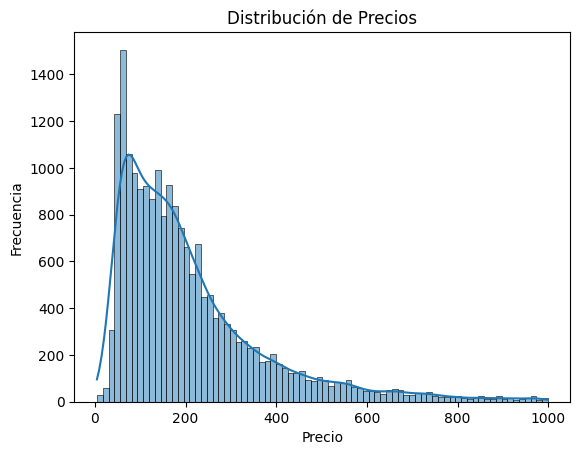

In [ ]:
df_new_price['price'] = df_new_price['price'].replace({'\\$': '', ',': ''}, regex=True).astype(float)

sns.histplot(df_new_price[df_new_price['price'] < 1000]['price'], kde=True)
plt.title('Distribución de Precios')
plt.xlabel('Precio')
plt.ylabel('Frecuencia')
plt.show()

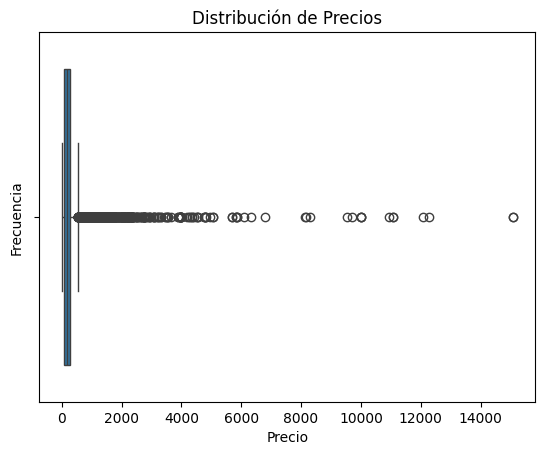

In [ ]:
sns.boxplot(x=df_new_price['price'])
plt.title('Distribución de Precios')
plt.xlabel('Precio')
plt.ylabel('Frecuencia')
plt.show()

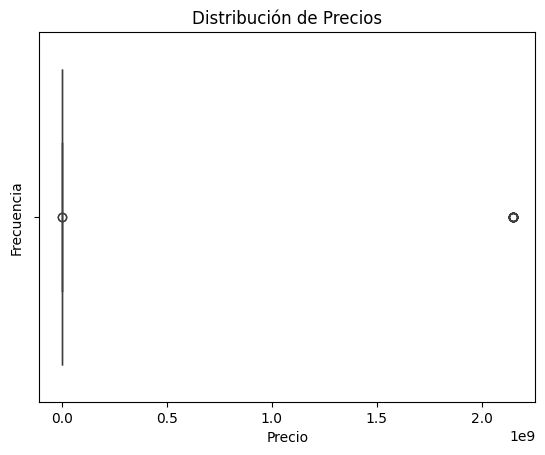

In [ ]:
sns.boxplot(x=df_new_price['maximum_nights'])
plt.title('Distribución de Precios')
plt.xlabel('Precio')
plt.ylabel('Frecuencia')
plt.show()

In [ ]:
df_new_price['price'].describe()

,price
count,20693.000000
mean,254.998857
std,440.478328
min,4.470000
25%,93.800000
50%,167.250000
75%,279.500000
max,15075.000000


In [ ]:
null_counts = df_new_price.isnull().sum()
print(null_counts[null_counts > 0].sort_values(ascending=False))

beds                        16966
bathrooms                   16938
license                     16182
bedrooms                     6408
review_scores_rating         5288
host_is_superhost             698
hosts_time_as_host_years      698
hosts_time_as_user_years      698
host_listings_count           698
host_identity_verified        698
maximum_nights                  1
minimum_nights                  1
dtype: int64


**Limpieza de datos para las camas, baños y habitacioens estan relacionadas con el tipo de propiedad y el tipo de cuarto**

In [ ]:
# Imputamos los baños basados en el tipo de propiedad
df_new_price['bathrooms'] = df_new_price['bathrooms'].fillna(df_new_price.groupby('property_type')['bathrooms'].transform('median'))
# Calculamos la mediana de camas según el tipo de habitación y rellenamos
df_new_price['beds'] = df_new_price['beds'].fillna(df_new_price.groupby('room_type')['beds'].transform('median'))
df_new_price['bedrooms'] = df_new_price['bedrooms'].fillna(df_new_price.groupby('property_type')['bedrooms'].transform('median'))

# La red de seguridad: rellena lo que el groupby no pudo
df_new_price['bathrooms'] = df_new_price['bathrooms'].fillna(df_new_price['bathrooms'].median())
df_new_price['bedrooms'] = df_new_price['bedrooms'].fillna(df_new_price['bedrooms'].median())

In [ ]:
null_counts = df_new_price.isnull().sum()
print(null_counts[null_counts > 0].sort_values(ascending=False))

license                     16182
review_scores_rating         5288
hosts_time_as_user_years      698
hosts_time_as_host_years      698
host_is_superhost             698
host_identity_verified        698
host_listings_count           698
maximum_nights                  1
minimum_nights                  1
dtype: int64


In [ ]:
df_new_price['license'].unique()

array([nan, 'OSE-STRREG-0000108', 'OSE-STRREG-0001710', ...,
       'OSE-STRREG-0003502', 'OSE-STRREG-0003527', 'OSE-STRREG-0003565'],
      dtype=object)

In [ ]:
# 1. Binarizar la licencia (1 si tiene texto, 0 si es NaN)
df_new_price['has_license'] = df_new_price['license'].notnull().astype(int)

In [ ]:
# Contamos cuántos de esos nulos tienen 0 reseñas totales
sin_resenas = df_new_price[df_new_price['review_scores_rating'].isna()]['number_of_reviews'].value_counts()
print(sin_resenas)

number_of_reviews
0    5288
Name: count, dtype: int64


**No todos los alojamientos son iguales. Si un Cuarto Compartido suele tener una calificación de 4.2 y una Casa Completa de 4.9, y nosotros usamos el promedio general (ej. 4.6) para rellenar los huecos, estaríamos dándole una calificación irrealmente alta al cuarto compartido o muy baja a la casa. Al agrupar por room_type, el modelo recibe información coherente con la categoría del anuncio, manteniendo las expectativas reales del mercado.**

In [ ]:
# 1. Imputación de experiencia del host (Mediana Global) 🌍
df_new_price['hosts_time_as_user_years'] = df_new_price['hosts_time_as_user_years'].fillna(df_new_price['hosts_time_as_user_years'].median())
df_new_price['hosts_time_as_host_years'] = df_new_price['hosts_time_as_host_years'].fillna(df_new_price['hosts_time_as_host_years'].median())

# 2. Imputación de Rating (Mediana por Tipo de Habitación) 🛌
df_new_price['review_scores_rating'] = df_new_price['review_scores_rating'].fillna(df_new_price.groupby('room_type')['review_scores_rating'].transform('median'))

In [ ]:
null_counts = df_new_price.isnull().sum()
print(null_counts[null_counts > 0].sort_values(ascending=False))

license                   16182
host_is_superhost           698
host_listings_count         698
host_identity_verified      698
minimum_nights                1
maximum_nights                1
dtype: int64


In [ ]:
df_new_price.groupby('has_license')['license'].count()

,license
has_license,
0,0
1,4511


In [ ]:
df_new_price[['host_identity_verified','host_is_superhost']].value_counts()

host_identity_verified  host_is_superhost
t                       f                    13613
                        t                     6107
f                       f                      253
                        t                       22
Name: count, dtype: int64

In [ ]:
# 1. Definimos la lista de columnas categóricas
columnas_categoricas = ['host_is_superhost', 'host_identity_verified']

# 2. Iniciamos el bucle para recorrer la lista
for col in columnas_categoricas:
    # Calculamos la moda de la columna actual
    moda = df_new_price[col].mode()[0]

    # Rellenamos los nulos en esa columna específica
    df_new_price[col] = df_new_price[col].fillna(moda)
    print(f"Columna '{col}' imputada con la moda: {moda}")

Columna 'host_is_superhost' imputada con la moda: f
Columna 'host_identity_verified' imputada con la moda: t


In [ ]:
null_counts = df_new_price.isnull().sum()
print(null_counts[null_counts > 0].sort_values(ascending=False))

license                16182
host_listings_count      698
minimum_nights             1
maximum_nights             1
dtype: int64


In [ ]:
# Calculamos la mediana de la misma columna y la usamos para rellenar
df_new_price['host_listings_count'] = df_new_price['host_listings_count'].fillna(df_new_price['host_listings_count'].median())

In [ ]:
null_counts = df_new_price.isnull().sum()
print(null_counts[null_counts > 0].sort_values(ascending=False))

license           16182
minimum_nights        1
maximum_nights        1
dtype: int64


In [ ]:
df_new_price['maximum_nights'] = df_new_price['maximum_nights'].fillna(df_new_price['maximum_nights'].median())
df_new_price['minimum_nights'] = df_new_price['minimum_nights'].fillna(df_new_price['minimum_nights'].median())

In [ ]:
null_counts = df_new_price.isnull().sum()
print(null_counts[null_counts > 0].sort_values(ascending=False))

license    16182
dtype: int64


In [ ]:
df_new_price.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20693 entries, 0 to 35035
Data columns (total 21 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   hosts_time_as_user_years      20693 non-null  float64
 1   hosts_time_as_host_years      20693 non-null  float64
 2   host_is_superhost             20693 non-null  object 
 3   host_listings_count           20693 non-null  float64
 4   host_identity_verified        20693 non-null  object 
 5   neighbourhood_cleansed        20693 non-null  object 
 6   neighbourhood_group_cleansed  20693 non-null  object 
 7   property_type                 20693 non-null  object 
 8   room_type                     20693 non-null  object 
 9   accommodates                  20693 non-null  int64  
 10  bathrooms                     20693 non-null  float64
 11  bedrooms                      20693 non-null  float64
 12  beds                          20693 non-null  float64
 13  amenit

<Axes: >

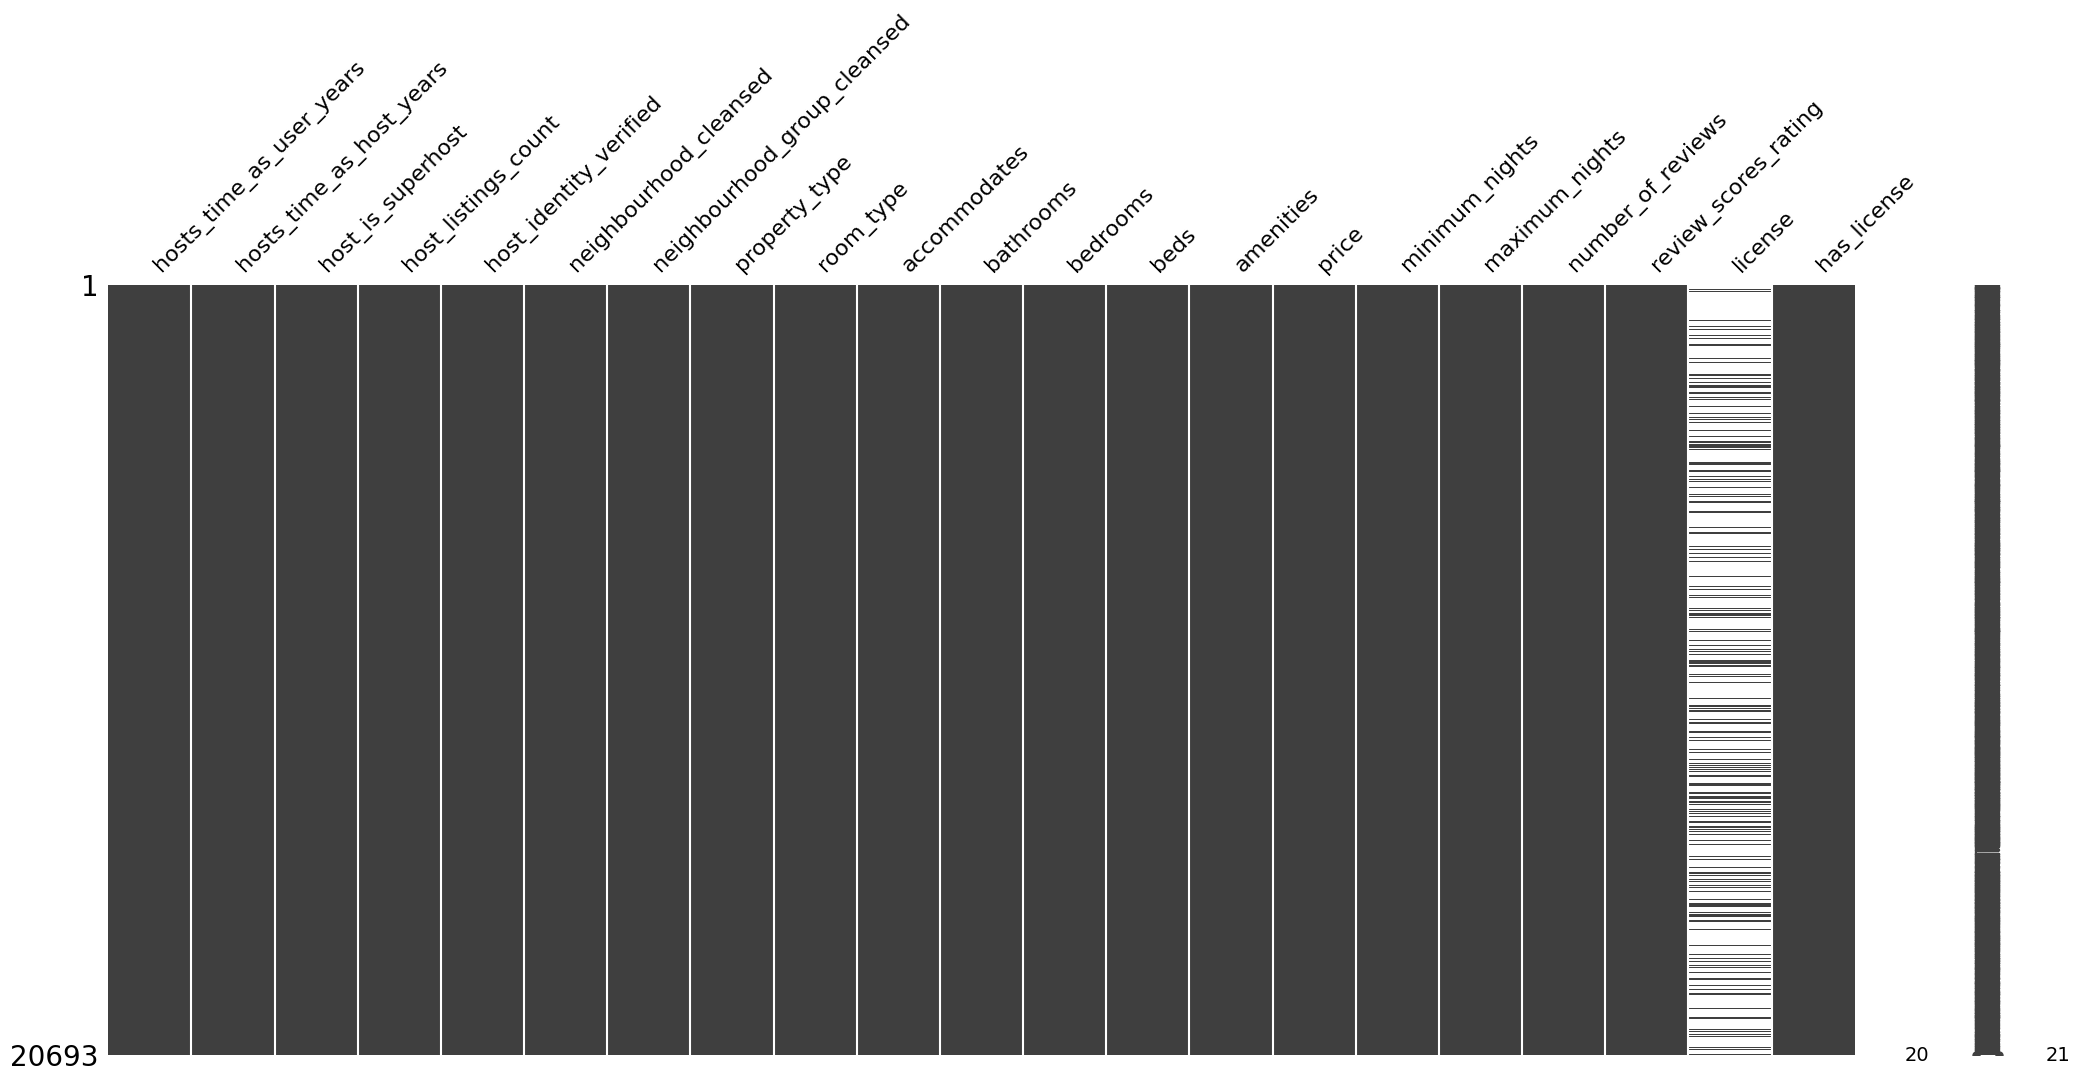

In [ ]:
import missingno as msno
msno.matrix(df_new_price)

In [ ]:
df_clean = df_new_price.copy()

In [ ]:
df_clean.groupby('has_license')['license'].count()

,license
has_license,
0,0
1,4511


In [ ]:
df_clean = df_clean.drop(['license'], axis = 1)

In [ ]:
df_clean.sample(1)

,hosts_time_as_user_years,hosts_time_as_host_years,host_is_superhost,host_listings_count,host_identity_verified,neighbourhood_cleansed,neighbourhood_group_cleansed,property_type,room_type,accommodates,bathrooms,bedrooms,beds,amenities,price,minimum_nights,maximum_nights,number_of_reviews,review_scores_rating,has_license
30392,8.0,4.0,t,4.0,t,Washington Heights,Manhattan,Private room in home,Private room,2,1.0,1.0,1.0,"[""Microwave"", ""Wifi"", ""Hangers"", ""Host greets ...",55.75,30.0,365.0,1,5.0,0


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


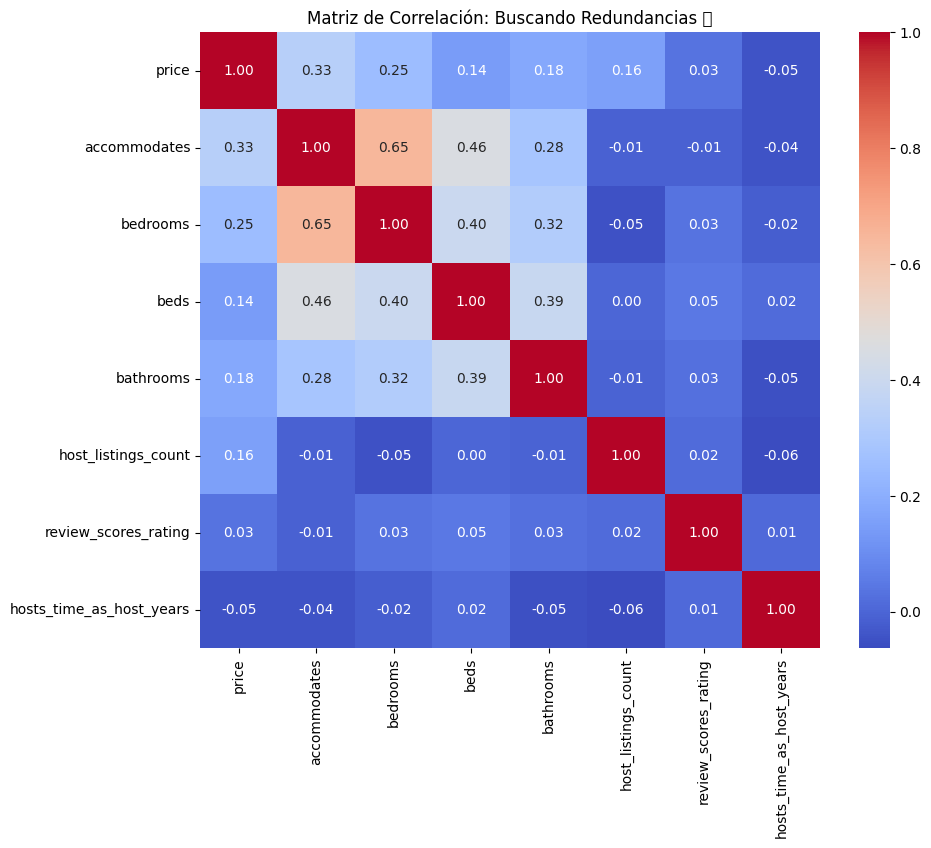

In [ ]:
# Seleccionamos las columnas numéricas que nos interesan
cols_interes = [
    'price', 'accommodates', 'bedrooms', 'beds', 'bathrooms',
    'host_listings_count', 'review_scores_rating',
    'hosts_time_as_host_years'
]

# Calculamos la correlación
corr_matrix = df_clean[cols_interes].corr()

# Dibujamos el mapa de calor
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlación: Buscando Redundancias 🔍')
plt.show()

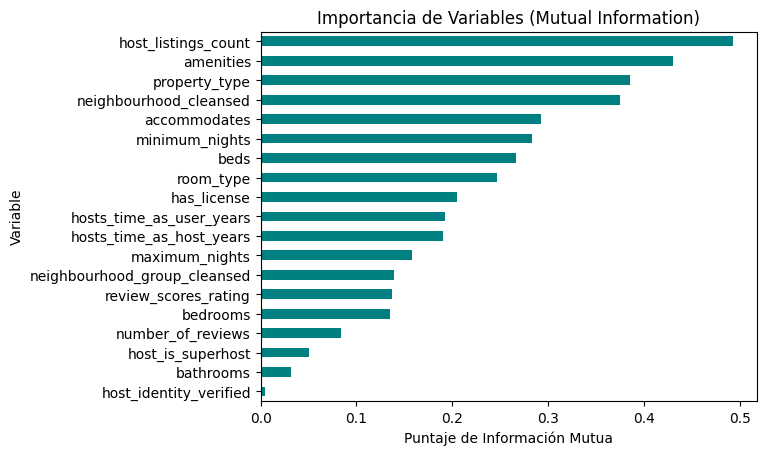

In [ ]:
from sklearn.feature_selection import mutual_info_regression


# Preparamos los datos (Mutual Info requiere valores numéricos, usamos un codificador simple para categorías)
X = df_clean.drop('price', axis=1)
for col in X.select_dtypes(include=['object']).columns:
    X[col] = X[col].astype('category').cat.codes

y = df_clean['price']
# Calculamos la información mutua
importancias = mutual_info_regression(X, y, random_state=42)
mi_series = pd.Series(importancias, index=X.columns).sort_values(ascending=True)

# Visualización
mi_series.plot(kind='barh', color='teal')
plt.title('Importancia de Variables (Mutual Information)')
plt.ylabel('Variable')
plt.xlabel('Puntaje de Información Mutua')
plt.show()

#TRANSFORMACIÓN Y GENERACIÓN DEL MODELO

In [ ]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20693 entries, 0 to 35035
Data columns (total 20 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   hosts_time_as_user_years      20693 non-null  float64
 1   hosts_time_as_host_years      20693 non-null  float64
 2   host_is_superhost             20693 non-null  object 
 3   host_listings_count           20693 non-null  float64
 4   host_identity_verified        20693 non-null  object 
 5   neighbourhood_cleansed        20693 non-null  object 
 6   neighbourhood_group_cleansed  20693 non-null  object 
 7   property_type                 20693 non-null  object 
 8   room_type                     20693 non-null  object 
 9   accommodates                  20693 non-null  int64  
 10  bathrooms                     20693 non-null  float64
 11  bedrooms                      20693 non-null  float64
 12  beds                          20693 non-null  float64
 13  amenit

In [ ]:
# Definimos el tope (por ejemplo, 365 días)
tope_noches = 365

# Aplicamos el capping
df_clean['maximum_nights'] = df_clean['maximum_nights'].clip(upper=tope_noches)

In [ ]:
limite_95 = df_clean['host_listings_count'].quantile(0.95)
df_clean['host_listings_count'] = df_clean['host_listings_count'].clip(upper=limite_95)

limite_99 = df_clean['number_of_reviews'].quantile(0.99)
df_clean['number_of_reviews'] = df_clean['number_of_reviews'].clip(upper=limite_99)

# Ejemplo para accommodates usando el percentil 99
limite_acc = df_clean['accommodates'].quantile(0.99)
df_clean['accommodates'] = df_clean['accommodates'].clip(upper=limite_acc)

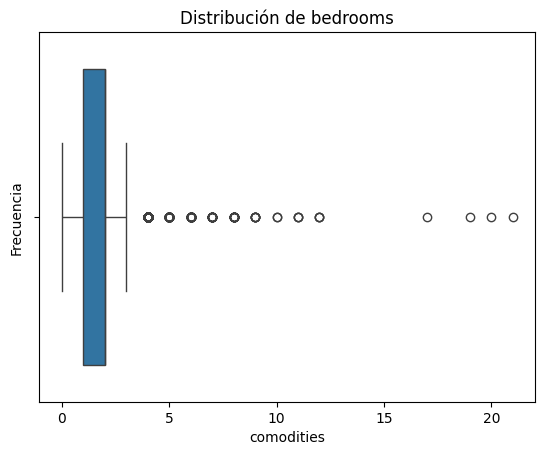

In [ ]:
sns.boxplot(x=df_clean['beds'])
plt.title('Distribución de bedrooms')
plt.xlabel('comodities')
plt.ylabel('Frecuencia')
plt.show()

In [ ]:
df_clean['host_listings_count'].describe()

,host_listings_count
count,20693.000000
mean,37.124632
std,80.158884
min,0.000000
25%,1.000000
50%,3.000000
75%,16.000000
max,281.000000


In [ ]:
# Reemplazamos el valor 0 por 0.5 específicamente en la columna de habitaciones
df_clean['bedrooms'] = df_clean['bedrooms'].replace(0, 0.5)

# Verificamos si aún quedan ceros
print(f"Ceros restantes en bedrooms: {(df_clean['bedrooms'] == 0).sum()}")

Ceros restantes en bedrooms: 0


In [ ]:
# Calculamos el ratio de camas por habitación
df_clean['beds_per_bedroom'] = df_clean['beds'] / df_clean['bedrooms']

# Miramos los casos más extremos (por ejemplo, donde hay más de 4 camas por cuarto)
extremos = df_clean[df_clean['beds_per_bedroom'] > 4]
print(extremos[['bedrooms', 'beds', 'accommodates', 'price']])

       bedrooms  beds  accommodates   price
10946       0.5   3.0             6  172.00
10992       0.5   3.0             6  330.00
11339       0.5   3.0             6  209.00
11467       0.5   3.0             6  486.50
11694       0.5   3.0             6  359.06
...         ...   ...           ...     ...
29170       0.5   3.0             5  231.60
29766       0.5   3.0             5  548.75
29898       1.0   5.0             9  375.38
30414       0.5   3.0             6  758.00
30990       1.0   6.0             6  362.50

[89 rows x 4 columns]


In [ ]:
df_clean.drop(['beds_per_bedroom'], axis=1, inplace=True)

In [ ]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20693 entries, 0 to 35035
Data columns (total 20 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   hosts_time_as_user_years      20693 non-null  float64
 1   hosts_time_as_host_years      20693 non-null  float64
 2   host_is_superhost             20693 non-null  object 
 3   host_listings_count           20693 non-null  float64
 4   host_identity_verified        20693 non-null  object 
 5   neighbourhood_cleansed        20693 non-null  object 
 6   neighbourhood_group_cleansed  20693 non-null  object 
 7   property_type                 20693 non-null  object 
 8   room_type                     20693 non-null  object 
 9   accommodates                  20693 non-null  int64  
 10  bathrooms                     20693 non-null  float64
 11  bedrooms                      20693 non-null  float64
 12  beds                          20693 non-null  float64
 13  amenit

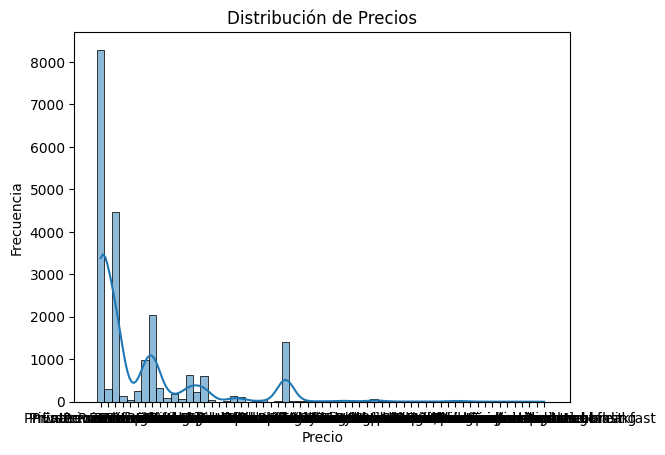

In [ ]:
sns.histplot(x=df_clean['property_type'], kde=True)
plt.title('Distribución de Precios')
plt.xlabel('Precio')
plt.ylabel('Frecuencia')
plt.show()

In [ ]:
df_clean['property_type'].value_counts().head(8)

,count
property_type,
Entire rental unit,8288
Private room in rental unit,4472
Private room in home,2043
Room in hotel,1403
Entire home,980
Entire condo,634
Private room in townhouse,603
Entire townhouse,323


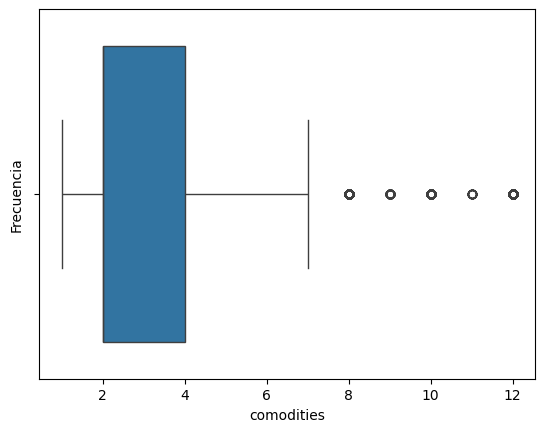

In [ ]:
sns.boxplot(x=df_clean['accommodates'])
plt.xlabel('comodities')
plt.ylabel('Frecuencia')
plt.show()

datos numericos buenos (StandarScaler o Noramlización):  
- hosts_time_as_user_years  
- hosts_time_as_host_years  
  
datos categoricos que se aplicará OneHotEncoder:   
- neighbourhood_group_cleansed
- has_licence    

datos numericos que se apliacrá OridnalEncoder:  
- room_type

categoricos con funciones:  
- amenities
- property_type
  
númericos con RobustScaler:  
- bathrooms  
- host_listings_count (aplicado .clip())
- accommodates (aplicado .clip())

númericos con logaritmo:  
- bedrooms  
- beds
- minimum_nights
- maximum_nights
- number_of_reviews (aplicado .clip())
- review_scores_rating

datos binarios:
- host_is_superhost
- host_identity_verified

función especial:  
- neighbourhood_cleansed

**LIMPIEZA FINALIZADA AHORA EMPIEZA LA TRANSFORMACIÓN Y ANÁLISIS DE VARIABLES CATEGORICAS**

In [ ]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20693 entries, 0 to 35035
Data columns (total 20 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   hosts_time_as_user_years      20693 non-null  float64
 1   hosts_time_as_host_years      20693 non-null  float64
 2   host_is_superhost             20693 non-null  object 
 3   host_listings_count           20693 non-null  float64
 4   host_identity_verified        20693 non-null  object 
 5   neighbourhood_cleansed        20693 non-null  object 
 6   neighbourhood_group_cleansed  20693 non-null  object 
 7   property_type                 20693 non-null  object 
 8   room_type                     20693 non-null  object 
 9   accommodates                  20693 non-null  int64  
 10  bathrooms                     20693 non-null  float64
 11  bedrooms                      20693 non-null  float64
 12  beds                          20693 non-null  float64
 13  amenit

In [ ]:
df_filtrado = df_clean[df_clean['price'] <= 800]

In [ ]:
X = df_filtrado.drop('price', axis=1)
y = df_filtrado['price']

print('Dimensiones dataset: {}'.format(df_clean.shape))
print('Dimensiones de X: {}'.format(X.shape))
print('Dimensiones de y: {}'.format(y.shape))

Dimensiones dataset: (20693, 20)
Dimensiones de X: (19953, 19)
Dimensiones de y: (19953,)


In [ ]:
# Ahora usaremos la función train test split que pertencen al paquete model_selection de sklearn

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,y, #primero pasamos los datos
    test_size = 0.3, # Determinamos la porción de los datos que se usará para probar el modelo, en este caso 30%
    random_state = 4, # Estado aleatorio - Semilla - seed, # reproducibilidad
    #stratify= y
)

print('Dimensiones de X de entrenamiento: {}'.format(X_train.shape))
print('Dimensiones de y de entrenamiento: {}\n'.format(y_train.shape))

print('Dimensiones de X de prueba: {}'.format(X_test.shape))
print('Dimensiones de y de prueba: {}'.format(y_test.shape))

Dimensiones de X de entrenamiento: (13967, 19)
Dimensiones de y de entrenamiento: (13967,)

Dimensiones de X de prueba: (5986, 19)
Dimensiones de y de prueba: (5986,)


In [ ]:
X_train.sample(2)

,hosts_time_as_user_years,hosts_time_as_host_years,host_is_superhost,host_listings_count,host_identity_verified,neighbourhood_cleansed,neighbourhood_group_cleansed,property_type,room_type,accommodates,bathrooms,bedrooms,beds,amenities,minimum_nights,maximum_nights,number_of_reviews,review_scores_rating,has_license
28207,8.0,8.0,f,281.0,t,Upper West Side,Manhattan,Entire rental unit,Entire home/apt,2,1.0,1.0,2.0,"[""Long term stays allowed"", ""Elevator"", ""Micro...",30.0,365.0,1.0,5.00,0
9004,8.0,8.0,f,3.0,t,Hell's Kitchen,Manhattan,Entire condo,Entire home/apt,2,1.0,1.0,2.0,"[""BBQ grill"", ""Shower gel"", ""Microwave"", ""Outd...",60.0,365.0,3.0,4.67,0


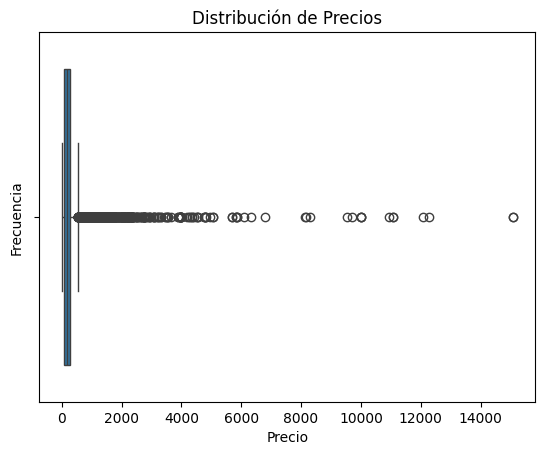

In [ ]:
sns.boxplot(x=df_clean['price'])
plt.title('Distribución de Precios')
plt.xlabel('Precio')
plt.ylabel('Frecuencia')
plt.show()

In [ ]:
import ast
import pandas as pd
import numpy as np

def count_amenities(X_series, max_val=40):
    """
    Counts the number of amenities in a column, capping at max_val.
    X_series is expected to be a pandas Series.
    """
    # Ensure X_series is actually a Series
    if not isinstance(X_series, pd.Series):
        # This should ideally not be reached if ColumnTransformer passes correctly
        if isinstance(X_series, pd.DataFrame) and X_series.shape[1] == 1:
            X_series = X_series.iloc[:, 0]
        else:
            raise TypeError(f"Expected pandas Series or single-column DataFrame, got {type(X_series)}")

    processed_values = []
    for x in X_series:
        try:
            # Evaluate string as a Python literal (e.g., list)
            # If not a string, or empty string, treat as empty list
            items = ast.literal_eval(x) if isinstance(x, str) and x.strip() else []
            processed_values.append(min(len(items), max_val))
        except (ValueError, SyntaxError):
            # Handle cases where literal_eval fails (e.g., malformed string)
            processed_values.append(0)
        except Exception: # Catch any other unexpected errors
            processed_values.append(0)

    # Ensure the output has the same number of rows as the input series
    return np.array(processed_values).reshape(-1, 1)

In [ ]:
#Función sencilla para convertir los binarios que tengan parametros de t (true) en 1 de lo contrario cero f (false)
def transformar_binarios(X):
    # Si X es 't', pone 1. Si no, pone 0.
    # Funciona para toda la columna de golpe.
    return np.where(X == 't', 1, 0)

In [ ]:
#función para las propiedades, al ser muchas 61 se decidio ahcer un top 7 según el hisplot era el mejor numero (Si no se dan las categorías (como en el fit), se calculamn),
def group_property_types(X, top_categories=None):
    # Pero para el Pipeline, lo ideal es pasarle la lista fija del Top 7
    X_copy = X.copy()
    X_copy[~X_copy.isin(top_categories)] = 'Other'
    return X_copy.values.reshape(-1, 1)

In [ ]:
standard_features = ['hosts_time_as_user_years', 'hosts_time_as_host_years']
onehot_features = ['neighbourhood_group_cleansed', 'has_license']
ordinal_features = ['room_type']
amenities_feature = 'amenities' # Changed from ['amenities'] to 'amenities'
top_7_properties = ['Entire rental unit','Private room in rental unit','Private room in home','Room in hotel','Entire home','Entire condo','Private room in townhouse']
robust_features = ['bathrooms', 'host_listings_count', 'accommodates']
log_features = ['bedrooms', 'beds', 'minimum_nights', 'maximum_nights', 'number_of_reviews', 'review_scores_rating']
binary_features = ['host_is_superhost', 'host_identity_verified']

In [ ]:
import category_encoders as ce
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, RobustScaler, OneHotEncoder, OrdinalEncoder, FunctionTransformer

amenities_transformer = Pipeline(steps=[
    ('conteo_capping', FunctionTransformer(count_amenities, kw_args={'max_val': 40}))
])

logaritm_transform = Pipeline([
            ('log', FunctionTransformer(np.log1p)),
            ('scaler', StandardScaler())
        ])

binarios_transformer = Pipeline(steps=[
    ('binarizar', FunctionTransformer(transformar_binarios))
])

property_transformer = Pipeline(steps=[
    ('agrupar', FunctionTransformer(group_property_types, kw_args={'top_categories': top_7_properties})),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

neighbourhood_transformer = ce.TargetEncoder()

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, RobustScaler, OneHotEncoder, OrdinalEncoder, FunctionTransformer

# Unimos todo en el preprocesador
preprocessor = ColumnTransformer(
    transformers=[
        # 1. Estandarización Normal
        ('std', StandardScaler(), standard_features),

        # 2. Categorías sin orden (OneHot)
        ('cat', OneHotEncoder(handle_unknown='ignore'), onehot_features),

        # 3. Categorías con orden (Ordinal)
        ('ord', OrdinalEncoder(categories=[['Shared room', 'Private room', 'Hotel room', 'Entire home/apt']]), ordinal_features),

        # 4. Amenities (Tu función de conteo) - Temporarily removed for debugging
        # ('amenities_pipe', amenities_transformer, amenities_feature),

        # 5. Escalado Robusto (Outliers)
        ('robust', RobustScaler(), robust_features),

        # 6. Logaritmo + Estandarización
        ('log_std', logaritm_transform, log_features),

        # 7. Binarios (Tu función personalizada)
        ('bin', binarios_transformer, binary_features),

        # 8. Función tipos de propiedad
        ('prop', property_transformer, ['property_type']),

        #9. Función de barrios
        ('neighbourhood', neighbourhood_transformer, 'neighbourhood_cleansed')

    ]
)

preprocessor

ColumnTransformer(transformers=[('std', StandardScaler(),
                                 ['hosts_time_as_user_years',
                                  'hosts_time_as_host_years']),
                                ('cat', OneHotEncoder(handle_unknown='ignore'),
                                 ['neighbourhood_group_cleansed',
                                  'has_license']),
                                ('ord',
                                 OrdinalEncoder(categories=[['Shared room',
                                                             'Private room',
                                                             'Hotel room',
                                                             'Entire '
                                                             'home/apt']]),
                                 ['room_type']),
                                ('robust', RobustScaler(),
                                 ['bathr...
                                                  FunctionTransformer(func=<function group_property_types at 0x7ea246b7f740>,
                                                                      kw_args={'top_categories': ['Entire '
                                                                                                  'rental '
                                                                                                  'unit',
                                                                                                  'Private '
                                                                                                  'room '
                                                                                                  'in '
                                                                                                  'rental '
                                                                                                  'unit',
                                                                                                  'Private '
                                                                                                  'room '
                                                                                                  'in '
                                                                                                  'home',
                                                                                                  'Room '
                                                                                                  'in '
                                                                                                  'hotel',
                                                                                                  'Entire '
                                                                                                  'home',
                                                                                                  'Entire '
                                                                                                  'condo',
                                                                                                  'Private '
                                                                                                  'room '
                                                                                                  'in '
                                                                                                  'townhouse']})),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 ['property_type']),
                                ('neighbourhood', TargetEncoder(),
                                 'neighbourhood_cleansed')])

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
#se crea el perceptor multicapa para regresión
mlp = MLPRegressor(hidden_layer_sizes=(100, 50), max_iter=500, random_state=42)

#Pipeline para Redes Neuronales (MLP)
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', mlp)
])

pipeline

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('std', StandardScaler(),
                                                  ['hosts_time_as_user_years',
                                                   'hosts_time_as_host_years']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['neighbourhood_group_cleansed',
                                                   'has_license']),
                                                 ('ord',
                                                  OrdinalEncoder(categories=[['Shared '
                                                                              'room',
                                                                              'Private '
                                                                              'room',
                                                                              'Hotel '
                                                                              'room',
                                                                              'Entire '
                                                                              'home/apt']]),
                                                  ['room_ty...
                                                                                                                   'unit',
                                                                                                                   'Private '
                                                                                                                   'room '
                                                                                                                   'in '
                                                                                                                   'home',
                                                                                                                   'Room '
                                                                                                                   'in '
                                                                                                                   'hotel',
                                                                                                                   'Entire '
                                                                                                                   'home',
                                                                                                                   'Entire '
                                                                                                                   'condo',
                                                                                                                   'Private '
                                                                                                                   'room '
                                                                                                                   'in '
                                                                                                                   'townhouse']})),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['property_type']),
                                                 ('neighbourhood',
                                                  TargetEncoder(),
                                                  'neighbourhood_cleansed')])),
                ('model',
                 MLPRegressor

In [ ]:
from xgboost import XGBRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline

# 1. Pipeline para XGBoost ⚡
pipeline_xgb = Pipeline(steps=[
    ('preprocessor', preprocessor), # El motor que ya armamos
    ('model', XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42))
])

# 2. Pipeline para KNN 👥
pipeline_knn = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', KNeighborsRegressor(n_neighbors=5))
])

# 3. Pipeline para Random Forest
pipeline_rf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(n_estimators=100, random_state=42))
])

# 4. Pipeline para Redes Neuronales (MLP)
pipeline_mlp = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', MLPRegressor(hidden_layer_sizes=(100, 50), max_iter=500, random_state=42))
])

In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.compose import TransformedTargetRegressor
import numpy as np

# Creamos un diccionario para organizar nuestros modelos
modelos = {
    'XGBoost': pipeline_xgb,
    'KNN': pipeline_knn,
    'Random Forest': pipeline_rf,
    'Red Neuronal': pipeline_mlp
}

# Aquí guardaremos los resultados
resultados_mae = {}

print("Iniciando validación cruzada... ⏳")

# Creamos un nuevo diccionario con los modelos "protegidos" por el logaritmo
modelos_log = {}

for nombre, pipeline in modelos.items():
    modelos_log[nombre] = TransformedTargetRegressor(
        regressor=pipeline,
        func=np.log1p,
        inverse_func=np.expm1
    )

for nombre, modelo_envuelto in modelos_log.items():
    # Ejecutamos validación cruzada con 5 pliegues (folds)
    # Usamos 'neg_mean_absolute_error' porque sklearn busca maximizar,
    # así que lo devuelve en negativo. Luego le damos la vuelta.
    scores = cross_val_score(modelo_envuelto, X_train, y_train,
                             cv=5,
                             scoring='neg_mean_absolute_error',
                             n_jobs=-1) # Usa todos los procesadores para ir más rápido

    mae_promedio = -scores.mean()
    resultados_mae[nombre] = mae_promedio
    print(f"{nombre} completado con transformación log. MAE: ${mae_promedio:.2f}")

Iniciando validación cruzada... ⏳
XGBoost completado con transformación log. MAE: $54.33
KNN completado con transformación log. MAE: $61.47
Random Forest completado con transformación log. MAE: $53.93
Red Neuronal completado con transformación log. MAE: $60.60


In [ ]:
print("Entrenando modelos finales con transformación logarítmica... 🧠")

for nombre, modelo_envuelto in modelos_log.items():
    # Entrenamos cada modelo formalmente para que pueda predecir
    modelo_envuelto.fit(X_train, y_train)
    print(f"✅ {nombre} listo para predecir.")

Entrenando modelos finales con transformación logarítmica... 🧠
✅ XGBoost listo para predecir.
✅ KNN listo para predecir.
✅ Random Forest listo para predecir.
✅ Red Neuronal listo para predecir.


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pandas as pd
import numpy as np

# 1. Usamos la lista para los nuevos resultados
resultados_finales = []

# 2. IMPORTANTE: Iteramos sobre modelos_log (los que tienen el logaritmo)
for nombre, modelo_envuelto in modelos_log.items():

    # El modelo_envuelto internamente hace: predict -> expm1 automáticamente
    predicciones = modelo_envuelto.predict(X_test)

    # Calculamos las métricas comparando dólares contra dólares
    mae = mean_absolute_error(y_test, predicciones)
    rmse = np.sqrt(mean_squared_error(y_test, predicciones))
    r2 = r2_score(y_test, predicciones)

    resultados_finales.append({
        'Model': nombre,
        'MAE ($)': round(mae, 2),
        'RMSE ($)': round(rmse, 2),
        'R² Score': round(r2, 4)
    })

# Creamos el DataFrame final y ordenamos por MAE (el menor es mejor)
df_resultados_log = pd.DataFrame(resultados_finales).sort_values('MAE ($)')
print(df_resultados_log)

           Model  MAE ($)  RMSE ($)  R² Score
2  Random Forest    50.76     82.00    0.6826
0        XGBoost    51.21     81.67    0.6852
3   Red Neuronal    58.95     91.95    0.6009
1            KNN    59.24     94.83    0.5756


In [ ]:
# Tomamos el mejor modelo (Random Forest)
mejor_modelo = modelos_log['Random Forest']
predicciones = mejor_modelo.predict(X_test)

# Creamos la tabla comparativa
df_comparativo = pd.DataFrame({
    'Precio Real': y_test,
    'Predicción': predicciones,
    'Diferencia ($)': np.abs(y_test - predicciones)
})

# Definimos un "Acierto" (ejemplo: si falló por menos del 25% del precio real)
df_comparativo['Acierto'] = df_comparativo['Diferencia ($)'] < (df_comparativo['Precio Real'] * 0.25)

print(df_comparativo.head(10))

# Calculamos el porcentaje total de aciertos
porcentaje_acierto = df_comparativo['Acierto'].mean() * 100
print(f"\n✨ El modelo acierta al precio (con 15% de margen) en un: {porcentaje_acierto:.2f}% de los casos")

       Precio Real  Predicción  Diferencia ($)  Acierto
18599       272.30  270.204710        2.095290     True
16259       248.00  319.441071       71.441071    False
2090         85.73   95.668852        9.938852     True
7581        342.07  288.767356       53.302644    False
16650        44.27   58.853683       14.583683    False
30269        90.80  121.001961       30.201961    False
15516       210.30  155.759856       54.540144    False
31134       414.83  419.793495        4.963495     True
8777         71.63   74.157390        2.527390     True
23127       207.23  268.418954       61.188954    False

✨ El modelo acierta al precio (con 15% de margen) en un: 42.11% de los casos


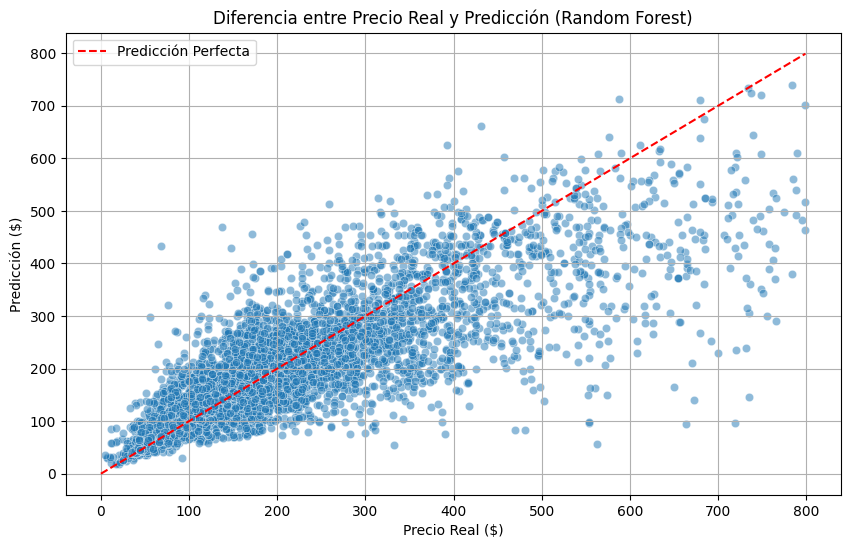

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

# Dibujamos los puntos
sns.scatterplot(x=df_comparativo['Precio Real'], y=df_comparativo['Predicción'], alpha=0.5)

# Dibujamos la línea de "Predicción Perfecta"
max_val = max(df_comparativo['Precio Real'].max(), df_comparativo['Predicción'].max())
plt.plot([0, max_val], [0, max_val], color='red', linestyle='--', label='Predicción Perfecta')

plt.title('Diferencia entre Precio Real y Predicción (Random Forest)')
plt.xlabel('Precio Real ($)')
plt.ylabel('Predicción ($)')
plt.legend()
plt.grid(True)
plt.show()